# Supporting 4 - Schedule screening on an unseen reservoir

*Optional detail; start with `notebooks/00_START_HERE.ipynb`.*

Monte Carlo screening (`5-Uncertainty.pdf` p.44-45) with the saved surrogates, then re-simulation. Limits are stated assumptions.

In [1]:
import sys, json, time
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
sys.path.insert(0, str(ROOT / 'src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display
from subsurfaceml.config import load_config

CONFIG = 'demo'                 # which completed run this notebook reads
cfg = load_config(ROOT / 'config' / f'{CONFIG}.yaml')
S = json.loads((Path(cfg.paths.metrics) / 'summary.json').read_text())
pd.set_option('display.max_colwidth', 80)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3,
                     'font.size': 9, 'figure.constrained_layout.use': True})


def provenance(kind, what):
    """Label every result: read from a finished run, or computed right here."""
    label = {'loaded': 'LOADED from the completed ' + CONFIG + ' run',
             'computed': 'COMPUTED NOW in this notebook session'}[kind]
    print(f'[{label}]  {what}')
from subsurfaceml.predict import Predictor
from subsurfaceml.optimise import SurrogateBundle, optimise_schedule, resimulate
from subsurfaceml.scenarios import sample_realisations
P = Predictor(cfg)   # verified artifacts; raises with a rebuild command if missing
b = SurrogateBundle(features=P.surrogates['dp_bh_max_MPa'].features,
    pressure=P.surrogates['dp_bh_max_MPa'], plume=P.surrogates['r_plume_m95_m'],
    band_pressure=P.bands['dp_bh_max_MPa'], band_plume=P.bands['r_plume_m95_m'])
rid = P.manifest['test_realisation_ids'][0]
r = {x.realisation_id: x for x in sample_realisations(cfg)}[rid]
print(r)

Realisation(realisation_id=5, seed=20266909, k_median_mD=134.11204468250142, V_DP=0.29445983898370515, phi_mean=0.100125454725802, h_total_m=55.675951880028805, r_e_m=3920.709078583676, n_g=2.582539068367288, n_a=3.632732783908552, krg0=0.25205453271261846, S_ar=0.19487009431677832, mu_g_cP=0.06197832761930318, rho_g=682.3460699232359)


In [2]:
s = optimise_schedule(cfg, r, b)
print(s['n_feasible'], 'of', s['n_candidates'], 'candidates predicted feasible')
rows = [resimulate(cfg, r, s['baseline']['rates_kg_s'], 'constant-rate baseline')]
rows += [resimulate(cfg, r, c['rates_kg_s'], f'screened {i}') for i, c in enumerate(s['shortlist'][:3])]
display(pd.DataFrame(rows)[['label','rates_kg_s','sim_mass_injected_Mt','sim_dp_bh_max_MPa',
                           'sim_r_plume_m95_m','violates_pressure','violates_plume']])

1955 of 3000 candidates predicted feasible


,label,rates_kg_s,sim_mass_injected_Mt,sim_dp_bh_max_MPa,sim_r_plume_m95_m,violates_pressure,violates_plume
0,constant-rate baseline,"[5.461808968401813, 5.461808968401813, 5.461808968401813, 5.461808968401813]",0.861808,6.383654,385.231202,False,False
1,screened 0,"[0.26308644029466177, 4.153822317830234, 7.571809264816138, 9.787622240942138]",0.859011,7.424666,386.073788,False,False
2,screened 1,"[5.067059300655148, 5.7945277297890625, 5.8049948732908705, 5.098460731160573]",0.858566,6.278195,384.752270,False,False
3,screened 2,"[4.041802467510214, 5.914767778680669, 6.322927423846865, 5.266281403008809]",0.849916,6.266319,383.650478,False,False


## All unseen reservoirs of the pipeline run

,realisation_id,baseline_mass_Mt,baseline_feasible_after_resimulation,n_screened_resimulated,n_screened_feasible,best_screened_mass_Mt,best_dp_MPa,best_rplume_m,improvement_pct
0,5,0.861808,True,3,3,0.859011,7.424666,386.073788,-0.324506
1,8,1.002708,True,3,3,1.032646,7.744313,250.570384,2.985692
2,9,0.488967,True,3,3,0.509973,7.745157,334.408457,4.296021
3,10,1.090084,True,3,3,1.120140,7.705111,349.231966,2.757243
4,11,1.092694,True,3,3,1.102255,5.358218,371.015596,0.874982


{'median_improvement_pct': 2.7572425786194565, 'n_realisations_improved': 4, 'n_realisations_compared': 5, 'n_screened_violating': 0, 'n_screened_resimulated': 15, 'n_baselines_violating': 0, 'n_failed_resimulations': 0}


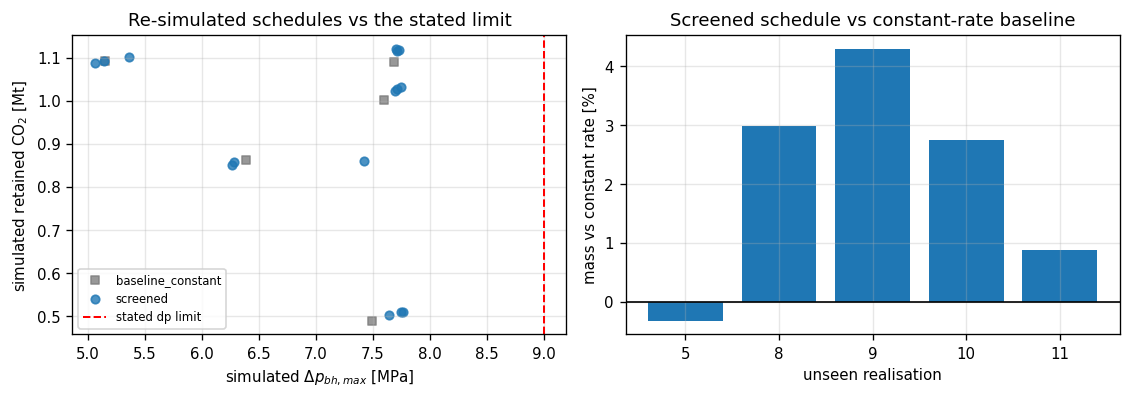

In [3]:
o = S['optimisation']
display(pd.DataFrame(o['per_realisation']))
print({k: o[k] for k in ('median_improvement_pct','n_realisations_improved','n_realisations_compared',
       'n_screened_violating','n_screened_resimulated','n_baselines_violating','n_failed_resimulations')})
display(Image(str(Path(cfg.paths.figures)/'15_schedule_screening.png')))